In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install -q transformers torch librosa datasets scikit-learn tqdm

In [1]:
import os
import numpy as np
import torch
import librosa
from tqdm import tqdm

from transformers import Wav2Vec2Processor, Wav2Vec2Model

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
# DATA_PATH = "/content/drive/MyDrive/SER_Project/"
DATA_PATH = "/home/ahmed/workspace/kfupm/ics504/project/original_datasets/"
# RAVDESS_FOLDERS = [DATA_PATH + "Ravdess_Song/", DATA_PATH + "Ravdess_Speech/"]
# TESS_FOLDER = DATA_PATH + "Tess/"
EYASE_FOLDER = DATA_PATH + "EYASE/"
RAVDESS_FOLDERS = [DATA_PATH + "ravdess/"]
TESS_FOLDER = DATA_PATH + "tess/"

In [25]:
EMOTION_LABELS = [
    "neutral", "calm", "happy", "sad",
    "angry", "fearful", "surprise", "disgust"
]
EMOTION_LABELS_EYASE = [
    "neutral", "happy", "sad","angry"
]


LABEL2IDX = {l:i for i,l in enumerate(EMOTION_LABELS)}

In [4]:
emotion_map_ravdess = {
    "01": "neutral","02": "calm","03": "happy","04": "sad",
    "05": "angry","06": "fearful","07": "disgust","08": "surprise",
}

emotion_map_tess = {
    "neutral":"neutral","happy":"happy","sad":"sad",
    "angry":"angry","fear":"fearful","disgust":"disgust",
    "pleasant_surprise":"surprise",
}

emotion_map_eyase = {
    "neu": "neutral",
    "hap": "happy",
    "sad": "sad",
    "ang": "angry"
}

In [5]:
def load_audio(file_path, sr=16000, max_len=5):
    audio, _ = librosa.load(file_path, sr=sr)
    max_samples = sr * max_len

    if len(audio) < max_samples:
        audio = np.pad(audio, (0, max_samples - len(audio)))
    else:
        audio = audio[:max_samples]

    return audio

In [6]:
def load_ravdess(folder_list):
    X, y = [], []

    for base in folder_list:
        for actor in os.listdir(base):
            actor_path = os.path.join(base, actor)

            if os.path.isdir(actor_path):
                for file in os.listdir(actor_path):
                    if file.endswith(".wav"):
                        parts = file.split("-")
                        if len(parts) < 3:
                            continue

                        label = emotion_map_ravdess.get(parts[2])

                        if label in LABEL2IDX:
                            X.append(load_audio(os.path.join(actor_path, file)))
                            y.append(LABEL2IDX[label])

    return X, y


def load_tess(folder):
    X, y = [], []

    for root,_,files in os.walk(folder):
        for file in files:
            if file.endswith(".wav"):
                name = file.split("_")[-1].replace(".wav","").lower()
                label = emotion_map_tess.get(name)

                if label in LABEL2IDX:
                    X.append(load_audio(os.path.join(root,file)))
                    y.append(LABEL2IDX[label])

    return X, y


def load_eyase(folder):
    X, y = [], []

    for root, _, files in os.walk(folder):
        for file in files:
            if file.endswith(".wav"):

                # Example: fm01_ang (1).wav
                parts = file.split("_")

                if len(parts) < 2:
                    continue

                emotion_code = parts[1][:3]  # ang, hap, sad, neu
                label = emotion_map_eyase.get(emotion_code)

                if label in LABEL2IDX:
                    path = os.path.join(root, file)
                    audio = load_audio(path)

                    X.append(audio)
                    y.append(LABEL2IDX[label])

    print(f"EYASE Loaded: {len(X)}")
    return X, y

In [7]:
X_r, y_r = load_ravdess(RAVDESS_FOLDERS)
X_t, y_t = load_tess(TESS_FOLDER)
X_e, y_e = load_eyase(EYASE_FOLDER)

# X = np.array(X_r + X_t + X_e, dtype=np.float32)
# y = np.array(y_r + y_t + y_e)

# print("Total:", len(X))

EYASE Loaded: 579


In [10]:
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.1, stratify=y, random_state=42
# )

X_train_r, X_temp_r, y_train_r, y_temp_r = train_test_split(
    X_r, y_r, test_size=0.1, stratify=y_r, random_state=42
)

X_test_r, X_val_r, y_test_r, y_val_r = train_test_split(
    X_temp_r, y_temp_r, test_size=0.5, stratify=y_temp_r, random_state=42 
)

X_train_t, X_temp_t,y_train_t, y_temp_t = train_test_split(
    X_t, y_t, test_size=0.1, stratify=y_t, random_state=42
)

X_test_t, X_val_t, y_test_t, y_val_t = train_test_split(
    X_temp_t, y_temp_t, test_size=0.5, stratify=y_temp_t, random_state=42
)

X_train_e, X_temp_e, y_train_e, y_temp_e = train_test_split(
    X_e, y_e, test_size=0.1, stratify=y_e, random_state=42
)

X_test_e, X_val_e, y_test_e, y_val_e = train_test_split(
    X_temp_e, y_temp_e, test_size=0.5, stratify=y_temp_e, random_state=42
)



In [12]:
X_train = np.array(X_train_r + X_train_t + X_train_e, dtype=np.float32)
y_train = np.array(y_train_r + y_train_t + y_train_e)

X_val = np.array(X_val_r + X_val_t + X_val_e, dtype=np.float32)
y_val = np.array(y_val_r + y_val_t + y_val_e)

X_test = np.array(X_test_r + X_test_t, dtype=np.float32)
y_test = np.array(y_test_r + y_test_t)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (3977, 80000), y_train: (3977,)
X_val: (221, 80000), y_val: (221,)
X_test: (192, 80000), y_test: (192,)


In [13]:
from collections import Counter

print("Class distribution:", Counter(y_train))

Class distribution: Counter({np.int64(4): 668, np.int64(3): 665, np.int64(2): 652, np.int64(0): 581, np.int64(5): 533, np.int64(7): 532, np.int64(1): 173, np.int64(6): 173})


In [14]:
MODEL_ID = "jonatasgrosman/wav2vec2-large-xlsr-53-english"

processor = Wav2Vec2Processor.from_pretrained(MODEL_ID)
base_model = Wav2Vec2Model.from_pretrained(MODEL_ID)

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: jonatasgrosman/wav2vec2-large-xlsr-53-english
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
class SERDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        audio = self.X[idx]
        label = self.y[idx]

        inputs = processor(
            audio,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        return inputs.input_values.squeeze(0), torch.tensor(label)

In [16]:
train_ds = SERDataset(X_train, y_train)
val_ds = SERDataset(X_val, y_val)
test_ds = SERDataset(X_test, y_test)
test_ds_e = SERDataset(X_test_e, y_test_e)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4)
test_loader = DataLoader(test_ds, batch_size=4)
test_loader_e = DataLoader(test_ds_e, batch_size=4)

In [17]:
class SERModel(nn.Module):
    def __init__(self, base_model, num_labels):
        super().__init__()
        self.wav2vec = base_model

        self.classifier = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels)
        )

    def forward(self, x):
        x = self.wav2vec(x).last_hidden_state
        x = x.mean(dim=1)
        return self.classifier(x)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SERModel(base_model, len(EMOTION_LABELS)).to(device)

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [20]:
train_losses = []
val_losses = []
val_accuracies = []

EPOCHS = 10

for epoch in range(EPOCHS):

    # ================= TRAIN =================
    model.train()
    total_loss = 0

    for x, y in tqdm(train_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)

        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()

            preds = torch.argmax(out, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

100%|██████████| 995/995 [02:34<00:00,  6.45it/s]


Epoch 1 | Train Loss: 1.0217 | Val Loss: 0.5300 | Val Acc: 0.8054


100%|██████████| 995/995 [02:33<00:00,  6.47it/s]


Epoch 2 | Train Loss: 0.4576 | Val Loss: 0.4193 | Val Acc: 0.8643


100%|██████████| 995/995 [02:33<00:00,  6.49it/s]


...

Epoch 8 | Train Loss: 0.1072 | Val Loss: 0.3208 | Val Acc: 0.9186


100%|██████████| 995/995 [02:33<00:00,  6.48it/s]


Epoch 9 | Train Loss: 0.0828 | Val Loss: 0.2395 | Val Acc: 0.9050


100%|██████████| 995/995 [02:32<00:00,  6.54it/s]


Epoch 10 | Train Loss: 0.0755 | Val Loss: 0.3373 | Val Acc: 0.9005


In [21]:
# SAVE_PATH = "/content/drive/MyDrive/SER_Project/ser_model.pth"
SAVE_PATH = "/home/ahmed/workspace/kfupm/ics504/project/ser_model.pth"

torch.save({
    "model_state": model.state_dict(),
    "labels": EMOTION_LABELS,
    "model_id": MODEL_ID
}, SAVE_PATH)

print("✅ Model saved at:", SAVE_PATH)

✅ Model saved at: /home/ahmed/workspace/kfupm/ics504/project/ser_model.pth



===== ENGLISH EMOTIONS CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

     neutral       0.92      0.92      0.92        25
        calm       0.91      1.00      0.95        10
       happy       0.93      0.83      0.88        30
         sad       0.85      0.97      0.90        29
       angry       0.97      0.97      0.97        29
     fearful       0.90      0.93      0.92        29
    surprise       1.00      0.60      0.75        10
     disgust       0.97      1.00      0.98        30

    accuracy                           0.92       192
   macro avg       0.93      0.90      0.91       192
weighted avg       0.93      0.92      0.92       192



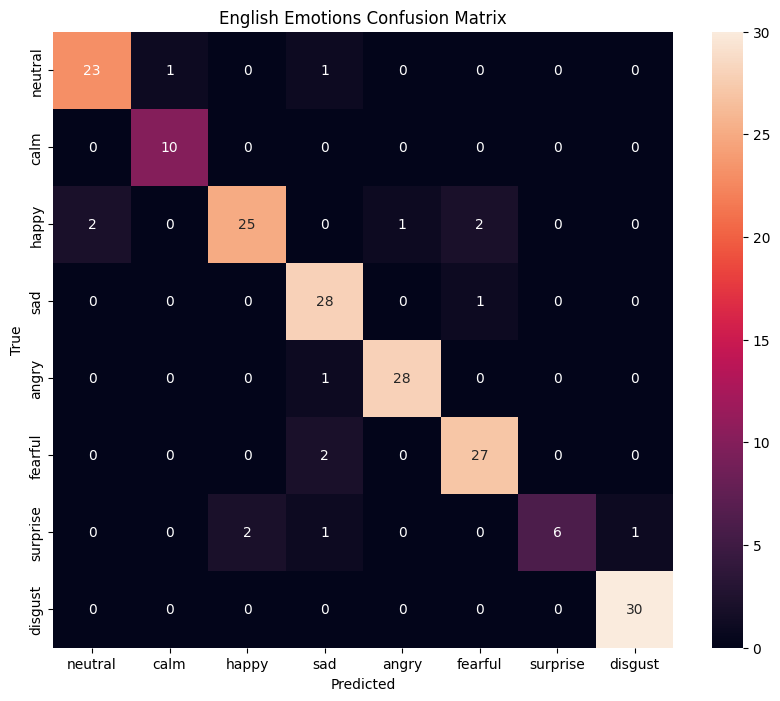

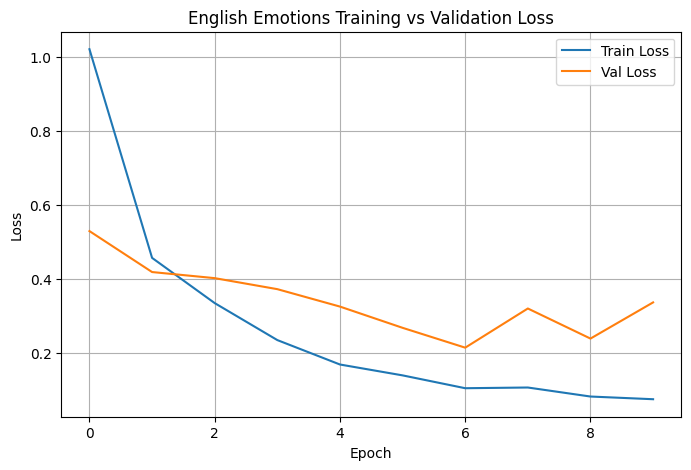

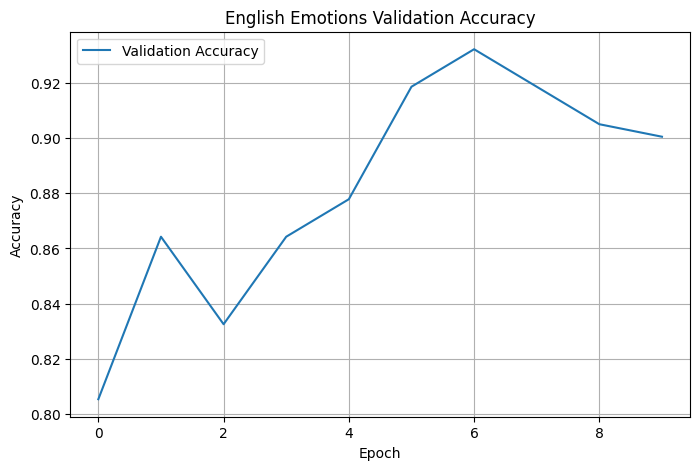

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ================= PREDICTIONS =================
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        y_true.extend(y.numpy())
        y_pred.extend(preds)

# ================= REPORT =================
print("\n===== ENGLISH EMOTIONS CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred, target_names=EMOTION_LABELS))

# ================= CONFUSION MATRIX =================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=EMOTION_LABELS,
            yticklabels=EMOTION_LABELS)

plt.title("English Emotions Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ================= LOSS CURVES =================
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("English Emotions Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# ================= ACCURACY CURVE =================
plt.figure(figsize=(8,5))
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("English Emotions Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


===== ARABIC EMOTIONS CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

     neutral       0.38      0.62      0.48         8
       happy       0.80      0.67      0.73         6
         sad       0.70      0.88      0.78         8
       angry       1.00      0.14      0.25         7

    accuracy                           0.59        29
   macro avg       0.72      0.58      0.56        29
weighted avg       0.71      0.59      0.56        29



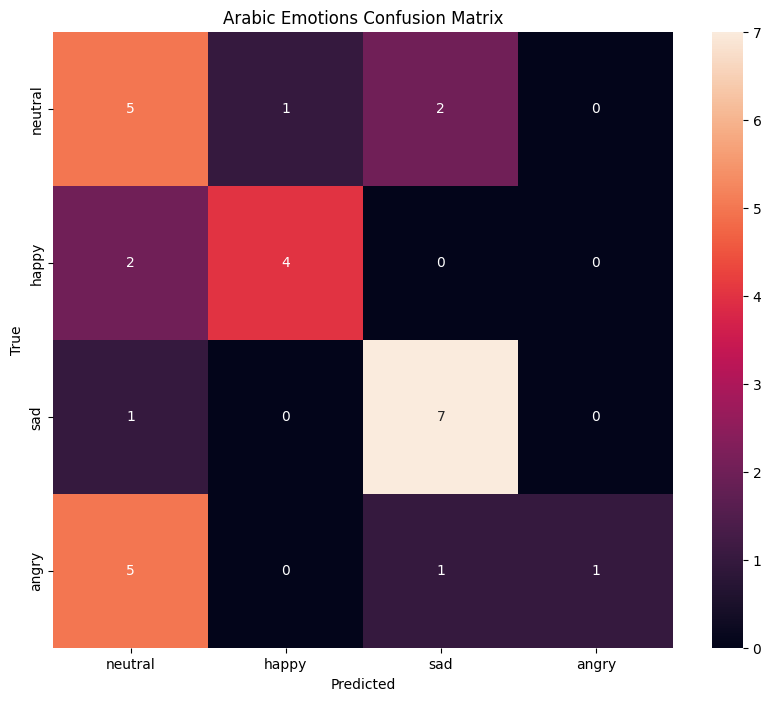

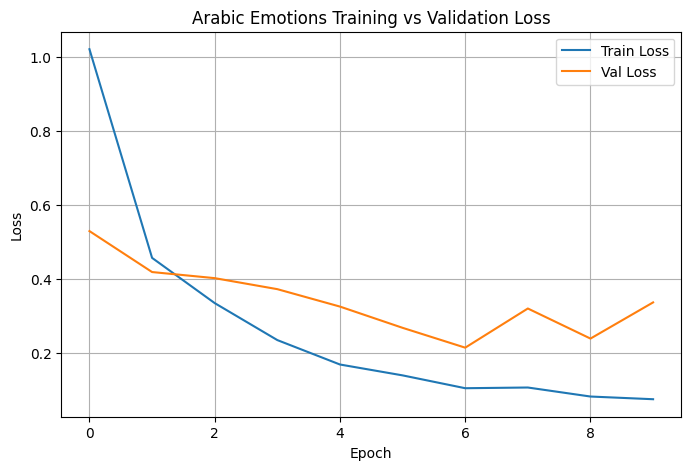

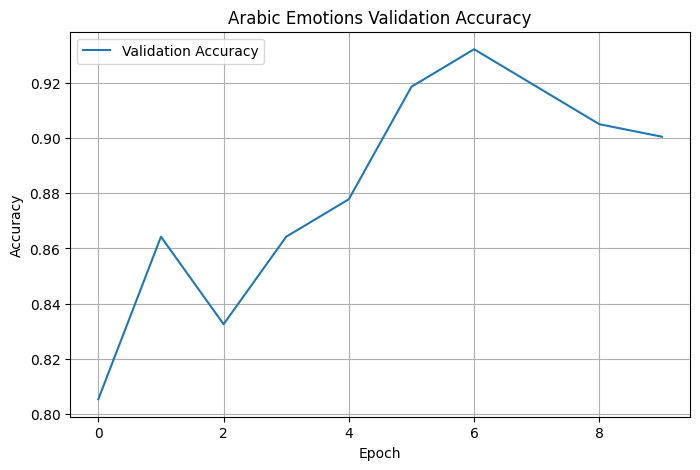

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ================= PREDICTIONS =================
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_loader_e:
        x = x.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        y_true.extend(y.numpy())
        y_pred.extend(preds)

# ================= REPORT =================
print("\n===== ARABIC EMOTIONS CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred, target_names=EMOTION_LABELS_EYASE))

# ================= CONFUSION MATRIX =================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=EMOTION_LABELS_EYASE,
            yticklabels=EMOTION_LABELS_EYASE)

plt.title("Arabic Emotions Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ================= LOSS CURVES =================
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Arabic Emotions Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# ================= ACCURACY CURVE =================
plt.figure(figsize=(8,5))
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Arabic Emotions Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()